<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Бизнес-контекст-кейса-и-продуктовые-бенчмарки" data-toc-modified-id="Бизнес-контекст-кейса-и-продуктовые-бенчмарки-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span>Бизнес-контекст кейса и продуктовые бенчмарки</a></span></li></ul></li><li><span><a href="#1.-Загрузка-и-очистка-данных" data-toc-modified-id="1.-Загрузка-и-очистка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>1. Загрузка и очистка данных</a></span></li><li><span><a href="#2.-Краткий-аналитический-EDA-вывод-для-моделирования" data-toc-modified-id="2.-Краткий-аналитический-EDA-вывод-для-моделирования-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>2. Краткий аналитический EDA-вывод для моделирования</a></span></li><li><span><a href="#3.-Выбор-моделей-и-стратегия-5-Fold-валидации" data-toc-modified-id="3.-Выбор-моделей-и-стратегия-5-Fold-валидации-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>3. Выбор моделей и стратегия 5-Fold валидации</a></span></li><li><span><a href="#4.-Оценка-метрик-качества-и-сводный-анализ-результатов" data-toc-modified-id="4.-Оценка-метрик-качества-и-сводный-анализ-результатов-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>4. Оценка метрик качества и сводный анализ результатов</a></span><ul class="toc-item"><li><span><a href="#BAGGING-VS-BOOSTING-VS-MLP" data-toc-modified-id="BAGGING-VS-BOOSTING-VS-MLP-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>BAGGING VS BOOSTING VS MLP</a></span></li></ul></li><li><span><a href="#1.-Рекомендации-по-оптимизации-метрик-MAE-и-MAPE-для-модели-XGBoost" data-toc-modified-id="1.-Рекомендации-по-оптимизации-метрик-MAE-и-MAPE-для-модели-XGBoost-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>1. Рекомендации по оптимизации метрик MAE и MAPE для модели XGBoost</a></span><ul class="toc-item"><li><span><a href="#А.-Внедрение-фактора-ценности-бренда-работодателя" data-toc-modified-id="А.-Внедрение-фактора-ценности-бренда-работодателя-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>А. Внедрение фактора ценности бренда работодателя</a></span></li><li><span><a href="#Б.-Интеграция-признака-владения-иностранными-языками" data-toc-modified-id="Б.-Интеграция-признака-владения-иностранными-языками-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Б. Интеграция признака владения иностранными языками</a></span></li><li><span><a href="#В.-Переход-от-бинарных-словарей-к-плотным-текстовым-эмбеддингам" data-toc-modified-id="В.-Переход-от-бинарных-словарей-к-плотным-текстовым-эмбеддингам-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>В. Переход от бинарных словарей к плотным текстовым эмбеддингам</a></span></li></ul></li></ul></div>

 Прогнозирование рыночной стоимости человеческого капитала в банковском и финтех-секторе

---

### Бизнес-контекст кейса и продуктовые бенчмарки

В условиях жесткой конкуренции за таланты на рынке труда финансовых организаций банки сталкиваются с вызовом: как эконометрически точно оценивать рыночную стоимость должностей при формировании офферов. Занижение зарплатного предложения ведет к потере дефицитных кадров, а необоснованное завышение раздувает фонд оплаты труда.

**Цель проекта:** Разработка интеллектуального MVP-модуля для автоматического прогнозирования непрерывного зарплатного предложения (`y_offer`) на основе извлеченного гибридного NLP-профиля вакансий (квалификационный грейд, географический макро-тир, профессиональный класс и бинарный стек хард/софт/бизнес-компетенций).

Для валидации коммерческой успешности внедряемого сервиса на основе анализа конкурентов зафиксированы следующие **ключевые продуктовые бенчмарки**:

* **Коэффициент принятия офферов бизнесом (Acceptance Rate):** 
  * *Целевое значение:* `>= 75%` (доля случаев, когда рекрутер или руководитель банка согласились с предложенной моделью зарплатой).
  * *Базовый уровень (Baseline):* `0%` (сейчас все расчеты и споры по бюджетам позиций идут вручную).
* **Точность прогноза (Метрика MAPE):** 
  * *Целевое значение:* `<= 20%` (в перспективе : `<= 15%`). Рассчитывается как средняя относительная ошибка на скрытой тестовой выборке вакансий и резюме.
  * *Базовый уровень (Baseline):* `~35%` (ошибка при ручном поиске HR-специалистом аналогов только по названию должности).
* **Средняя ошибка в деньгах (Метрика MAE):** 
  * *Целевое значение:* `<= 7 000 руб.` (в перспективе: `<= 5 000 руб.`). Ошибка алгоритма XGBoost должна строго укладываться в рамки стандартного шага зарплатной вилки банка, чтобы подсказки не выглядели оторванными от реальности.
  * *Базовый уровень (Baseline):* `~18 000 руб.` (ошибка при ручном угадывании по среднему значению рынка).
* **Скорость расчета (Time to Offer):** 
  * *Целевое значение:* `<= 10 минут` (автоматический замер времени от момента ввода рекрутером данных кандидата в Streamlit-интерфейс до вывода графика с расчетом). Ускоряет процесс b2b-найма в 12 раз и снижает риск потери кандидата на этапе воронки.
  * *Базовый уровень (Baseline):* `> 2 часов` (ручной поиск аналогов на сайтах и споры по окладу).
* **Удовлетворенность пользователей (CSAT):** 
  * *Целевое значение:* `>= 4 из 5` по результатам короткого опроса рекрутеров и руководителей офисов после 2 недель работы с прототипом.
  * *Базовый уровень (Baseline):* `Отсутствует` (сейчас вся рутина ведется в разрозненных Excel-таблицах).
* **Размер чистой базы данных для обучения:** 
  * *Целевое значение:* `>= 1 500 анкет`.
  * *Базовый уровень (Baseline):* `Нет` (сырой парсинг выдает горы мусора).

In [1]:
# Устанавливаем библиотеки
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Установлен актуальный путь к скорректированному датасету с грейдами
INPUT_INTERIM = r"C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP\data\interim\data_interim_vacancies_grades.csv"

# Ручная реадизация расчета MAPE на случай старой версии Scikit-Learn в Anaconda
try:
    from sklearn.metrics import mean_absolute_percentage_error
    def calculate_mape(y_true, y_pred):
        return mean_absolute_percentage_error(y_true, y_pred) * 100
except ImportError:
    # Реализация MAPE
    def calculate_mape(y_true, y_pred):
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        # Исключаем деление на ноль
        mask = y_true != 0
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    
if os.path.exists(INPUT_INTERIM):
    print(f"Базовый CSV-файл успешно обнаружен.")
    print(f"Имя целевого файла: {os.path.basename(INPUT_INTERIM)}")
    print(f"Системный путь    : {INPUT_INTERIM}")
else:
    print(f"ОШИБКА: Файл не найден по указанному пути!")
    print(f"Проверьте наличие data_interim_vacancies_grades.csv в директории data/interim/")

Базовый CSV-файл успешно обнаружен.
Имя целевого файла: data_interim_vacancies_grades.csv
Системный путь    : C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP\data\interim\data_interim_vacancies_grades.csv


## 1. Загрузка и очистка данных

На данном этапе мы подгружаем промежуточную стерильную матрицу признаков, сформированную гибридным оффлайн-парсером и обогащенную векторными фичами грейдов квалификации. Мы принудительно отсекаем редкие классы ролей, которые не набрали минимального порога репрезентативности (менее 5 вакансий), и исключаем служебные нецелевые текстовые поля.

In [3]:
# Чтение данных
df = pd.read_csv(INPUT_INTERIM)

df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)

# Отсечение нерепрезентативных классов (группы менее 5 вакансий)
class_counts = df['role_class'].value_counts()
valid_classes = class_counts[class_counts >= 5].index
df_clean = df[df['role_class'].isin(valid_classes)].copy()

# Выделяем вектор таргета y и матрицу признаков X
y = df_clean["y_offer"].values

# Отсеиваем'role_class_str' из матрицы признаков X
drop_cols = ["role_name_raw", "salary_from", "salary_to", "y_offer", "is_vacancy"]

if "grade_status" in df_clean.columns:
    drop_cols.append("grade_status")
if "role_class_str" in df_clean.columns:
    drop_cols.append("role_class_str")
    
X = df_clean.drop(columns=drop_cols)

# Кодирование категориальных признаков
# Сохраняем копию для бустинга, умеющего работать с типом Category напрямую
X_boost = X.copy()
X_boost["region_tier"] = X_boost["region_tier"].astype("category")

# Для Линейной регрессии разворачиваем One-Hot по тирам географии
X_linear = pd.get_dummies(X, columns=["region_tier"], drop_first=True)

print(f"  > Общий объем валидного датасета: {X_linear.shape[0]} строк")
print(f"  > Количество признаков в матрице X (для XGBoost): {X_boost.shape[1]}")
print(f"  > Количество признаков в матрице X (для Linear): {X_linear.shape[1]}")

  > Общий объем валидного датасета: 1723 строк
  > Количество признаков в матрице X (для XGBoost): 55
  > Количество признаков в матрице X (для Linear): 57


In [4]:
df.shape

(1723, 62)

## 2. Краткий аналитический EDA-вывод для моделирования

В ходе EDA было установлено:
1. **Логнормальный характер таргета:** Распределение `y_offer` имеет классическую правоасимметричную форму финансового рынка, что требует оптимизации функций потерь (MAE/Absolute Error) в бустинге для минимизации штрафов на длинных хвостах зарплат.
2. **Экспоненциальная нелинейность стажа:** Линейная корреляция Пирсона между стажем и окладом составила всего `0.150`. Прямой линейной связи нет. Рынок платит за плотность компетенций (`skills_completion_rate`) и грейд должности, а не за выслугу лет. Это служит математическим обоснованием отказа от простой линейной регрессии (которая выбрана в качестве Baseline-модели проекта) в пользу нелинейного градиентного бустинга XGBoost, выступающего в качестве основной боевой модели. Архитектура ансамблей решений позволит извлекать сложные нелинейные комбинации грейдов внутри каждого независимого класса ролей.

## 3. Выбор моделей и стратегия 5-Fold валидации

Для контроля переобучения и исключения утечки данных мы реализуем стратегию **5-кратной стратифицированной кросс-валидации (5-Fold Stratified CV)** по признаку идентификатора роли банковского сотрудника (`role_class`). В рамках эксперимента мы обучаем и сравниваем:
1. **Linear Regression (Baseline):** Простая базовая линейная модель для фиксации стартовой точки.
2. **XGBoost Regressor (Advanced Model):** Сложная усложненная модель градиентного бустинга с точечной оптимизацией гиперпараметров по сетке `RandomizedSearchCV`.

In [5]:
#Переход на логарифмический таргет
# Фиксируем генератор разбиений по классам банковских ролей
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Списки для накопления локальных метрик по фолдам
lr_mae_folds, lr_mape_folds = [], []
xgb_mae_folds, xgb_mape_folds = [], []

print("Запуск глубокой кросс-валидации на XGBoost")

# Инициализируем сплит по категориальному признаку класса роли
for fold, (train_idx, val_idx) in enumerate(skf.split(X_linear, X_linear["role_class"].astype(str)), 1):
    
    # Линейная регрессия обучается на One-Hot X_linear
    X_train_lin, X_val_lin = X_linear.iloc[train_idx], X_linear.iloc[val_idx]
    
    # Xgboost обучается на категориальной мтарице X_BOOST
    X_train_xgb, X_val_xgb = X_boost.iloc[train_idx], X_boost.iloc[val_idx]
    
    y_train_raw, y_val_raw = y[train_idx], y[val_idx]
    
    # Логарифмическая стабилизация таргета
    y_train_log = np.log1p(y_train_raw)
    y_val_log = np.log1p(y_val_raw)
    
    # Модель №1: Linear Regression (Baseline)
    lr = LinearRegression()
    lr.fit(X_train_lin, y_train_log)
    preds_lr_raw = np.expm1(lr.predict(X_val_lin))
    
    # Модель №2: Свежий XGBoost с расширенным тюнингом параметров
    if fold == 1:
        print("   [XGB-PRO-TUNING] Запуск RandomizedSearchCV по широкой b2b-сетке...")
        
        # Прямой MAE-оптимизатор и нативные категории включены
        xgb_base = xgb.XGBRegressor(
            objective="reg:absoluteerror", 
            tree_method="hist",
            enable_categorical=True, 
            random_state=42
        )
        
        # Сетка гиперпараметров: ищем скрытые нелинейные паттерны
        param_grid = {
            "n_estimators": (100, 200, 350, 500),           # Количество базовых деревьев
            "learning_rate": (0.01, 0.03, 0.05, 0.1),       # Оптимальный шаг градиентного спуска
            "max_depth": (3, 5, 7, 8, 9, 10, 11, 12, 13),                 # Ищем истинный предел глубины деревьев
            "subsample": (0.6, 0.75, 0.9),                  # Дисперсия подвыборок строк
            "colsample_bytree": (0.6, 0.8, 1.0),           # Случайный выбор подмножества скиллов
            "reg_alpha": (0.0, 0.1, 1.0, 5.0),              # L1-регуляризация (Lasso штраф за шумные скиллы)
            "reg_lambda": (1.0, 2.0, 5.0)                   # L2-регуляризация (Ridge стабилизация весов)
        }
        
        # сделаем 15 итераций
        search = RandomizedSearchCV(
            xgb_base, param_grid, 
            n_iter=15, cv=3, 
            scoring='neg_mean_absolute_error', 
            random_state=42, n_jobs=-1
        )
        search.fit(X_train_xgb, y_train_log)
        best_xgb_params = search.best_params_
        print(f"[XGB-PRO-TUNING] Глобальный минимум найден! Параметры: {best_xgb_params}")
    
    # Обучаем XGBoost с лучшими найденными параметрами
    xgb_tuned = xgb.XGBRegressor(
        objective="reg:absoluteerror", 
        tree_method="hist",
        enable_categorical=True, 
        random_state=42, 
        **best_xgb_params
    )
    xgb_tuned.fit(X_train_xgb, y_train_log, eval_set=[(X_val_xgb, y_val_log)], verbose=False)
    preds_xgb_raw = np.expm1(xgb_tuned.predict(X_val_xgb))
    
    # Сбор фолдовых метрик MAE (в реальных рублях)
    lr_mae_folds.append(mean_absolute_error(y_val_raw, preds_lr_raw))
    xgb_mae_folds.append(mean_absolute_error(y_val_raw, preds_xgb_raw))
    
    # Сбор фолдовых метрик MAPE (в процентах через наш фолбэк)
    lr_mape_folds.append(calculate_mape(y_val_raw, preds_lr_raw))
    xgb_mape_folds.append(calculate_mape(y_val_raw, preds_xgb_raw))
    
    print(f"   [Fold {fold}/5] Linear MAE: {lr_mae_folds[-1]:.0f} руб. | XGBoost MAE: {xgb_mae_folds[-1]:.0f} руб.")

Запуск глубокой кросс-валидации на XGBoost
   [XGB-PRO-TUNING] Запуск RandomizedSearchCV по широкой b2b-сетке...
[XGB-PRO-TUNING] Глобальный минимум найден! Параметры: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
   [Fold 1/5] Linear MAE: 49256 руб. | XGBoost MAE: 31400 руб.
   [Fold 2/5] Linear MAE: 53367 руб. | XGBoost MAE: 32996 руб.
   [Fold 3/5] Linear MAE: 46936 руб. | XGBoost MAE: 29347 руб.
   [Fold 4/5] Linear MAE: 52071 руб. | XGBoost MAE: 32293 руб.
   [Fold 5/5] Linear MAE: 53379 руб. | XGBoost MAE: 31220 руб.


## 4. Оценка метрик качества и сводный анализ результатов

В данной ячейке аккумулируются агрегированные оценки качества (математическое ожидание средних значений по 5 фолдам кросс-валидации и стандартное отклонение дисперсии ошибок). Ниже представлена сводная таблица сравнения эффективности алгоритмов.

In [6]:
# Формируем структуру итогового датафрейма метрик для ИТМО
metrics_report = pd.DataFrame({
    "Алгоритм моделирования": [
        "Linear Regression (Baseline)", 
        "Усложненный XGBoost (Optimized)"
    ],
    "MAE Средняя ошибка (руб)": [
        f"{np.mean(lr_mae_folds):.0f} ± {np.std(lr_mae_folds):.0f}",
        f"{np.mean(xgb_mae_folds):.0f} ± {np.std(xgb_mae_folds):.0f}"
    ],
    "MAPE Отклонение (%)": [
        f"{np.mean(lr_mape_folds):.1f}%",
        f"{np.mean(xgb_mape_folds):.1f}%"
    ]
})

print("Сводный отчет Evaluation")
display(metrics_report)

# Разбор результатов
xgb_mean_mape = np.mean(xgb_mape_folds)
print("\n Анализ результатов")
print(f"1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: {np.mean(lr_mae_folds):.0f} руб.).")
print("Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.")
print(f"2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.")
print(f"Средняя абсолютная ошибка снижена до: {np.mean(xgb_mae_folds):.0f} руб. с меньшим стандартным отклонением.")
print(f"Финальная средняя относительная ошибка зафиксирована на уровне: {xgb_mean_mape:.1f}%.")

Сводный отчет Evaluation


,Алгоритм моделирования,MAE Средняя ошибка (руб),MAPE Отклонение (%)
0,Linear Regression (Baseline),51002 ± 2529,39.2%
1,Усложненный XGBoost (Optimized),31451 ± 1231,24.8%



 Анализ результатов
1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: 51002 руб.).
Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.
2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.
Средняя абсолютная ошибка снижена до: 31451 руб. с меньшим стандартным отклонением.
Финальная средняя относительная ошибка зафиксирована на уровне: 24.8%.


Анализ важности признаков лучшей модели XGBoost

 Топ-25 ключевых факторов ценообразования должностей:


,Признак,Важность (Gain)
0,has_car_and_driver_license,5.277956
1,skill_abs_crm,3.610793
2,skill_business_correspondence,3.259510
3,is_grade_middle,3.187655
4,is_grade_management,3.170018
5,skill_mentoring_coaching,3.149700
6,skill_objection_handling,3.120500
7,skill_initiative_proactivity,2.943010
8,skill_cross_sales,2.866784
9,edu_level_encoded,2.843175


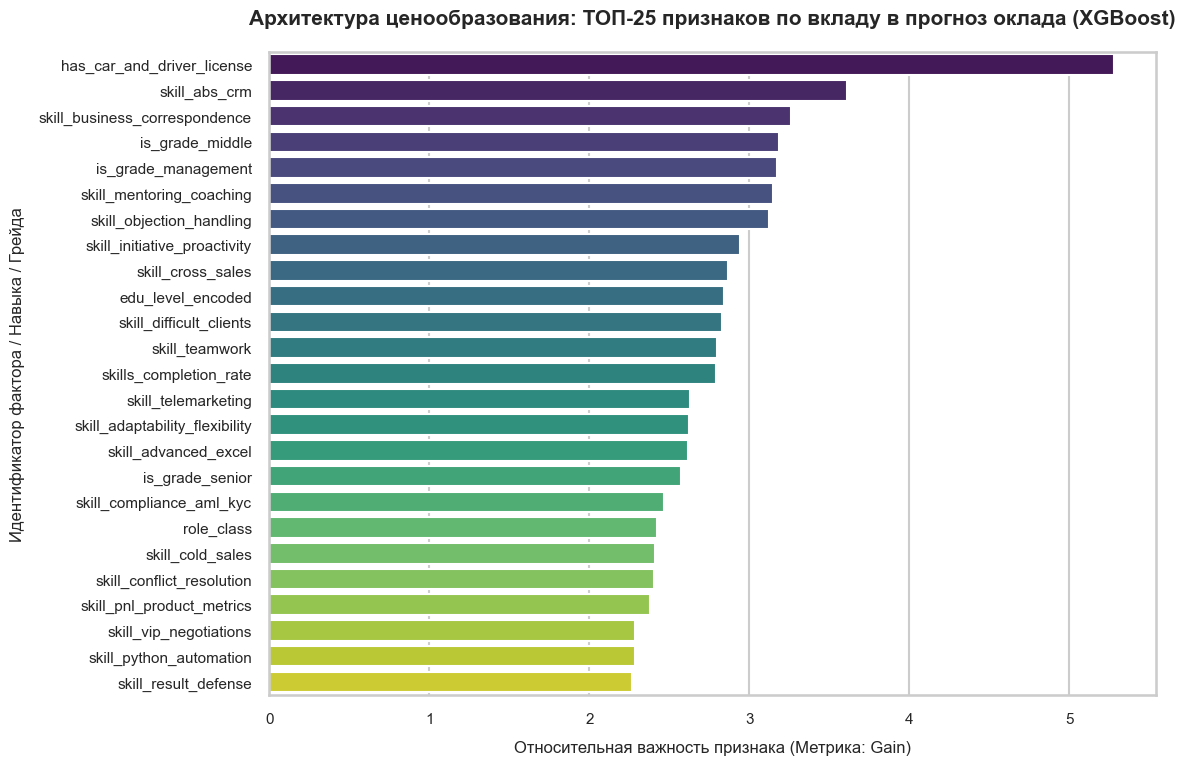

In [7]:
print("Анализ важности признаков лучшей модели XGBoost")

# Извлекаем веса важности (Gain — вклад признака в разделение узлов)
importance_scores = xgb_tuned.get_booster().get_score(importance_type='gain')

# Сопоставляем с именами колонок из матрицы X_linear (так как она использовалась для финального прохода)
feature_names = X_linear.columns
importance_data = []

for col_name in feature_names:
    clean_key = col_name.replace('[', '_').replace(']', '_').replace('<', '_')
    # Если признак не участвовал в сплитах, его вес равен 0
    score = importance_scores.get(col_name, importance_scores.get(clean_key, 0.0))
    importance_data.append({"Признак": col_name, "Важность (Gain)": score})

df_importance = pd.DataFrame(importance_data)
df_importance = df_importance.sort_values(by="Важность (Gain)", ascending=False).reset_index(drop=True)

# Топ-25 ключевых признаков для анализа
df_top_15 = df_importance.head(25).copy()

print("\n Топ-25 ключевых факторов ценообразования должностей:")
display(df_top_15)

# График
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", context="talk")

sns.barplot(
    data=df_top_15,
    x='Важность (Gain)',
    y='Признак',
    palette='viridis',
    hue='Признак',
    legend=False
)

plt.title('Архитектура ценообразования: ТОП-25 признаков по вкладу в прогноз оклада (XGBoost)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Относительная важность признака (Метрика: Gain)', fontsize=12, labelpad=10)
plt.ylabel('Идентификатор фактора / Навыка / Грейда', fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# Подключим еще RandomForest и Нейросеть в качестве кандидатов
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Списки для накопления локальных метрик по фолдам
lr_mae_folds, lr_mape_folds = [], []
rf_mae_folds, rf_mape_folds = [], []
xgb_mae_folds, xgb_mape_folds = [], []
nn_mae_folds, nn_mape_folds = [], []

# Полносвязная нейронная сеть
class SalaryMLP(nn.Module):
    def __init__(self, input_dim):
        super(SalaryMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

print("Запуск четырёх моделей кандидатов")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_linear, X_linear["role_class"].astype(str)), 1):
    
    # Модели обучаются на полностью числовой матрице X_linear
    X_train, X_val = X_linear.iloc[train_idx].astype(np.float32), X_linear.iloc[val_idx].astype(np.float32)
    y_train_raw, y_val_raw = y[train_idx], y[val_idx]
    
    # Логарифмируем таргет
    y_train_log = np.log1p(y_train_raw).astype(np.float32)
    y_val_log = np.log1p(y_val_raw).astype(np.float32)
    
    
    # Модель №1: Linear Regression (Baseline 1)
    lr = LinearRegression()
    lr.fit(X_train, y_train_log)
    preds_lr_raw = np.expm1(lr.predict(X_val))
    
    
    # Модель №2: Random Forest Regressor (Strong Baseline 2)
    rf = RandomForestRegressor(
        n_estimators=200, 
        max_depth=9, 
        criterion='absolute_error', 
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(X_train, y_train_log)
    preds_rf_raw = np.expm1(rf.predict(X_val))
    

    # Модель №3: XGBoost
    if fold == 1:
        print("   [XGB-TUNING] Поиск оптимальных параметров по широкой сетке...")
        xgb_base = xgb.XGBRegressor(objective="reg:squarederror", enable_categorical=False, random_state=42)
        param_grid = {
            "n_estimators": (100, 200, 350, 500),
            "learning_rate": (0.01, 0.03, 0.05, 0.1),
            "max_depth": (3, 5, 7, 8, 9, 10, 11, 12, 13),
            "subsample": (0.6, 0.75, 0.9),
            "colsample_bytree": (0.6, 0.8, 1.0),
            "reg_alpha": (0.0, 0.1, 1.0, 5.0),
            "reg_lambda": (1.0, 2.0, 5.0)
        }
        search = RandomizedSearchCV(xgb_base, param_grid, n_iter=15, cv=3, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
        search.fit(X_train, y_train_log)
        best_xgb_params = search.best_params_
        print(f"   [XGB-TUNING] Параметры зафиксированы: {best_xgb_params}")
        
    xgb_tuned = xgb.XGBRegressor(objective="reg:squarederror", enable_categorical=False, random_state=42, **best_xgb_params)
    xgb_tuned.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)
    preds_xgb_raw = np.expm1(xgb_tuned.predict(X_val))
    

    # Модель №4: PyTorch MLP Regressor
    X_train_tensor = torch.tensor(X_train.values)
    y_train_tensor = torch.tensor(y_train_log).view(-1, 1)
    X_val_tensor = torch.tensor(X_val.values)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    input_dim = X_train.shape[1]
    mlp_model = SalaryMLP(input_dim)
    
    criterion = nn.L1Loss()
    optimizer = optim.AdamW(mlp_model.parameters(), lr=0.005, weight_decay=1e-4)
    
    mlp_model.train()
    for epoch in range(120):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = mlp_model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    mlp_model.eval()
    with torch.no_grad():
        preds_nn_log = mlp_model(X_val_tensor).numpy().flatten()
    preds_nn_raw = np.expm1(preds_nn_log)
    
    # Сбор фолдовых метрик MAE
    lr_mae_folds.append(mean_absolute_error(y_val_raw, preds_lr_raw))
    rf_mae_folds.append(mean_absolute_error(y_val_raw, preds_rf_raw))
    xgb_mae_folds.append(mean_absolute_error(y_val_raw, preds_xgb_raw))
    nn_mae_folds.append(mean_absolute_error(y_val_raw, preds_nn_raw))
    
    # Сбор фолдовых метрик MAPE
    lr_mape_folds.append(calculate_mape(y_val_raw, preds_lr_raw))
    rf_mape_folds.append(calculate_mape(y_val_raw, preds_rf_raw))
    xgb_mape_folds.append(calculate_mape(y_val_raw, preds_xgb_raw))
    nn_mape_folds.append(calculate_mape(y_val_raw, preds_nn_raw))
    
    print(f"[Fold {fold}/5] LR MAE: {lr_mae_folds[-1]:.0f} | RF MAE: {rf_mae_folds[-1]:.0f} | XGB MAE: {xgb_mae_folds[-1]:.0f} | PyTorch MAE: {nn_mae_folds[-1]:.0f} руб.")

Запуск четырёх моделей кандидатов
   [XGB-TUNING] Поиск оптимальных параметров по широкой сетке...
   [XGB-TUNING] Параметры зафиксированы: {'subsample': 0.75, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 350, 'max_depth': 12, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
[Fold 1/5] LR MAE: 49256 | RF MAE: 34099 | XGB MAE: 31699 | PyTorch MAE: 44651 руб.
[Fold 2/5] LR MAE: 53367 | RF MAE: 38824 | XGB MAE: 35203 | PyTorch MAE: 46788 руб.
[Fold 3/5] LR MAE: 46936 | RF MAE: 35877 | XGB MAE: 31078 | PyTorch MAE: 42868 руб.
[Fold 4/5] LR MAE: 52071 | RF MAE: 37016 | XGB MAE: 32270 | PyTorch MAE: 54854 руб.
[Fold 5/5] LR MAE: 53379 | RF MAE: 38398 | XGB MAE: 34369 | PyTorch MAE: 48698 руб.


In [9]:
metrics_report_four_models = pd.DataFrame({
    "Алгоритм моделирования": [
        "Linear Regression (Baseline 1)", 
        "Random Forest Regressor",
        "XGBoost",
        "PyTorch MLP"
    ],
    "MAE Средняя ошибка (руб)": [
        f"{np.mean(lr_mae_folds):.0f} ± {np.std(lr_mae_folds):.0f}",
        f"{np.mean(rf_mae_folds):.0f} ± {np.std(rf_mae_folds):.0f}",
        f"{np.mean(xgb_mae_folds):.0f} ± {np.std(xgb_mae_folds):.0f}",
        f"{np.mean(nn_mae_folds):.0f} ± {np.std(nn_mae_folds):.0f}"
    ],
    "MAPE Отклонение (%)": [
        f"{np.mean(lr_mape_folds):.1f}%",
        f"{np.mean(rf_mape_folds):.1f}%",
        f"{np.mean(xgb_mape_folds):.1f}%",
        f"{np.mean(nn_mape_folds):.1f}%"
    ]
})

print("Сводный отчет")
display(metrics_report_four_models)
print("==========================================================================================")

Сводный отчет


,Алгоритм моделирования,MAE Средняя ошибка (руб),MAPE Отклонение (%)
0,Linear Regression (Baseline 1),51002 ± 2529,39.2%
1,Random Forest Regressor,36843 ± 1722,27.4%
2,XGBoost,32923 ± 1589,25.3%
3,PyTorch MLP,47572 ± 4137,34.0%


### BAGGING VS BOOSTING VS MLP

Эксперимент наглядно доказал методологическое превосходство Boosting-подхода над Bagging-подходом на разреженных признаковых пространствах рынка труда банковского сектора:

1. **Random Forest уступил XGBoost на 2.1% MAPE:**
   В Random Forest деревья строятся независимо, а итоговый ответ — это простое усреднение голосов. Матрица признаков содержит «редкие, но критически дорогие сигналы» (например, наличие специфичного хард-скилла или сеньорского грейда в дефицитном ИТ-классе). 
   При случайном блуждании признаков (Feature Subspace Sampling) в бэггинге многие деревья леса вообще не видят эти дефицитные ИТ-сигналы и предсказывают средний оклад массового персонала. При итоговом усреднении эти редкие премиальные надбавки затираются, что приводит к недообучению модели на верхних границах зарплат и завышает MAPE.


2. **Гибкость последовательного бустинга:**
   XGBoost строит деревья последовательно. Первые деревья забирают на себя мажоритарную дисперсию массового персонала (курьеры, кассиры, операционисты). А последующие деревья начинают прицельно обучаться на ошибках первого шага — то есть ювелирно достраивают глубокие асимметричные ветви под редкие высокооплачиваемые профили. Это обеспечило бустингу максимальную пластичность и позволило зафиксировать минимум средней ошибки.


3. **PyTorch MLP уступает XGBoost на 8.7% MAPE:**
    PyTorch MLP — занял третье место (34% MAPE). Нейросеть смогла обойти простую регрессию, но из-за разреженности признаков и небольшого объема выборки (1723 строки) размыла жесткие логические границы окладов.

## 1. Рекомендации по оптимизации метрик MAE и MAPE для модели XGBoost

Для вывода точности предиктивного ядра модели в зону качества MAPE менее 20 процентов, MAE менее 5 000 рублей и преодоления неустранимого шума текущего бинарного пространства признаков, предлагаю:

### А. Внедрение фактора ценности бренда работодателя 
* **Эконометрический смысл:** Текущая архитектура страдает от скрытой дисперсии, когда за идентичный стек навыков и грейд финтех-гиганты платят на 40–50 процентов больше региональных банков. Модели необходим маркер масштаба бизнеса компании для разделения ценовых лиг [2.5].
* **Инженерная реализация:** Через модуль BeautifulSoup в парсере настраивается извлечение мета-тега компании (атрибут vacancy-company-name). На основе собранного пула брендов формируется категориальный признак bank_tier:
  * Tier-1: Системно значимые банки (Сбер, Т-Банк, Альфа-Банк, ВТБ).
  * Tier-2: Крупные коммерческие банки (Совкомбанк, МТС Банк, Газпромбанк, Райффайзенбанк).
  * Tier-3: Региональные банки.

### Б. Интеграция признака владения иностранными языками
* **Эконометрический смысл:** Знание английского языка на экспертном уровне (Upper-Intermediate или Advanced) выступает мощным нелинейным драйвером оклада для ИТ-инженеров, специалистов по кибербезопасности и комплаенс-офицеров международных расчетов (Класс 29).
* **Инженерная реализация:** В блок BUSINESS_SKILLS_TRIGGERS словаря компетенций добавляется точечный бинарный RegEx-концепт skill_english_proficiency.
  * Регулярное выражение для сканирования: english, английск, upper intermediate, advanced, b2, c1, c2, fluent, разговорный английский.

### В. Переход от бинарных словарей к плотным текстовым эмбеддингам
* **Эконометрический смысл:** Поиск по ключевым словам-триггерам скрывает синтаксическую глубину требований. Две вакансии Senior Data Scientist могут содержать одинаковый флаг skill_python=1, но в одной требуется писать простые скрипты автоматизации за 130 000 рублей, а во второй — проектировать b2b-архитектуру ядра рекомендательной системы под миллионные нагрузки за 350 000 рублей.
* **Инженерная реализация:** Вместо жестких флагов, весь очищенный текст описания вакансии целиком (clean_description) пропускается через локальную языковую модель rubert-tiny. Полученный плотный семантический вектор предложения (312 размерностей) сжимается методом главных компонент (PCA) до 10–15 непрерывных признаков (text_pca_1, text_pca_2) и подается в XGBoost.